In [1]:
# Task 1: Supervised Learning - House Price Prediction
# Objective: Predict house prices using labeled data from Kaggle
# Dataset: House Prices - Advanced Regression Techniques

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [5]:
print( " House Price Prediction - Supervised Learning Task ")

 House Price Prediction - Supervised Learning Task 


In [6]:
# load dataset

In [8]:
print("Step 1: Loading the dataset")
# Download from Kaggle: House Prices - Advanced Regression Techniques
# Place train.csv in your working directory

Step 1: Loading the dataset


In [12]:
try:
    df = pd.read_csv('train.csv')
    print(f"Dataset loaded successfully! Shape: {df.shape}")
    print(f"Columns: {len(df.columns)}")
except FileNotFoundError:
    print("Please download 'train.csv' from Kaggle House Prices dataset")
    print("Link: https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data")


Dataset loaded successfully! Shape: (1460, 81)
Columns: 81


In [13]:
# Step 2: Explore the data
print("\nStep 2: Data Exploration...")
print("First few rows:")
print(df.head())


Step 2: Data Exploration...
First few rows:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  Sal

In [14]:
print(f"\nTarget variable statistics (SalePrice):")
print(df['SalePrice'].describe())


Target variable statistics (SalePrice):
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [15]:
print(f"\nMissing values in dataset:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0].sort_values(ascending=False))



Missing values in dataset:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


In [16]:
# Step 3: Data preprocessing

In [17]:
print("\nStep 3: Data Preprocessing...")


Step 3: Data Preprocessing...


In [18]:
# Select key features for simplicity (following project guideline: Keep It Simple)
selected_features = [
    'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 
    'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea',
    'BedroomAbvGr', 'TotRmsAbvGrd', 'GarageCars', 'GarageArea'
]

In [19]:
# Create a clean dataset with selected features
df_clean = df[selected_features + ['SalePrice']].copy()

In [20]:
# Handle missing values by filling with median
for column in df_clean.columns:
    if df_clean[column].isnull().sum() > 0:
        df_clean[column].fillna(df_clean[column].median(), inplace=True)

In [21]:
print(f"Clean dataset shape: {df_clean.shape}")
print("Missing values after cleaning:", df_clean.isnull().sum().sum())

Clean dataset shape: (1460, 13)
Missing values after cleaning: 0


In [22]:
# Step 4: Feature selection and target separation
print("\nStep 4: Preparing features and target...")
X = df_clean.drop('SalePrice', axis=1)  # Features
y = df_clean['SalePrice']               # Target variable



Step 4: Preparing features and target...


In [23]:
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")


Features shape: (1460, 12)
Target shape: (1460,)


In [24]:
# Step 5: Split the data
print("\nStep 5: Splitting data into train and test sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")



Step 5: Splitting data into train and test sets...
Training set: 1168 samples
Test set: 292 samples


In [25]:
# Step 6: Train models
print("\nStep 6: Training machine learning models...")



Step 6: Training machine learning models...


In [26]:
# Model 1: Linear Regression
print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

Training Linear Regression...


LinearRegression()

In [27]:
# Model 2: Random Forest (generally performs better)
print("Training Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

Training Random Forest...


RandomForestRegressor(random_state=42)

In [28]:
# Step 7: Make predictions
print("\nStep 7: Making predictions...")
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)



Step 7: Making predictions...


In [29]:
# Step 8: Evaluate models
print("\nStep 8: Model Evaluation...")



Step 8: Model Evaluation...


In [30]:
# Step 8: Evaluate models
print("\nStep 8: Model Evaluation...")

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{model_name} Performance:")
    print(f"Mean Absolute Error: ${mae:,.2f}")
    print(f"Root Mean Square Error: ${rmse:,.2f}")
    print(f"R² Score: {r2:.4f}")
    return mae, rmse, r2

lr_metrics = evaluate_model(y_test, lr_pred, "Linear Regression")
rf_metrics = evaluate_model(y_test, rf_pred, "Random Forest")


Step 8: Model Evaluation...

Linear Regression Performance:
Mean Absolute Error: $23,270.09
Root Mean Square Error: $37,788.02
R² Score: 0.8138

Random Forest Performance:
Mean Absolute Error: $17,759.36
Root Mean Square Error: $27,913.28
R² Score: 0.8984


In [31]:
# Step 9: Visualize results
print("\nStep 9: Creating visualizations...")
plt.figure(figsize=(15, 5))



Step 9: Creating visualizations...


<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

Text(0.5, 1.0, 'Random Forest: Actual vs Predicted Prices')

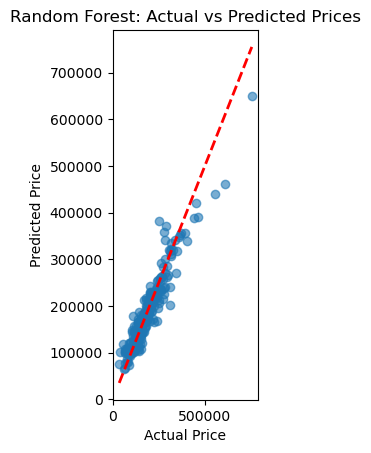

In [34]:
#Plot 1: Actual vs Predicted price
plt.subplot(1, 3, 1)
plt.scatter(y_test, rf_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest: Actual vs Predicted Prices')

Text(0.5, 1.0, 'Feature Importance (Random Forest)')

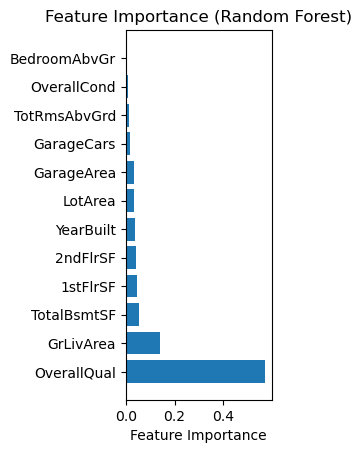

In [36]:
# Plot 2: Feature importance
plt.subplot(1, 3, 2)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.barh(range(len(feature_importance)), feature_importance['importance'])
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance (Random Forest)')


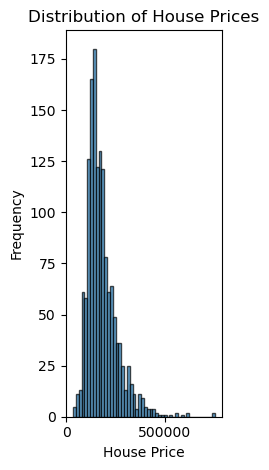

In [37]:
# Plot 3: Price distribution
plt.subplot(1, 3, 3)
plt.hist(y, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('House Price')
plt.ylabel('Frequency')
plt.title('Distribution of House Prices')

plt.tight_layout()
plt.show()


In [38]:
# Step 10: Make sample predictions
print("\nStep 10: Sample Predictions...")
print("Making predictions on first 5 test samples:")
sample_predictions = rf_model.predict(X_test.head())
sample_actual = y_test.head()

comparison_df = pd.DataFrame({
    'Actual_Price': sample_actual.values,
    'Predicted_Price': sample_predictions,
    'Difference': sample_actual.values - sample_predictions
})
print(comparison_df)



Step 10: Sample Predictions...
Making predictions on first 5 test samples:
   Actual_Price  Predicted_Price  Difference
0        154500        143066.25    11433.75
1        325000        320090.79     4909.21
2        115000        119586.75    -4586.75
3        159000        160993.50    -1993.50
4        315500        322432.23    -6932.23


In [39]:
# Summary
print("\n" + "="*60)
print("TASK 1 COMPLETED: SUPERVISED LEARNING")
print("="*60)
print(f"✓ Dataset: House Prices from Kaggle")
print(f"✓ Algorithm: Random Forest Regression")
print(f"✓ Best Model R² Score: {rf_metrics[2]:.4f}")
print(f"✓ Mean Absolute Error: ${rf_metrics[0]:,.2f}")
print("✓ Model can predict house prices based on key features")
print("="*60)


TASK 1 COMPLETED: SUPERVISED LEARNING
✓ Dataset: House Prices from Kaggle
✓ Algorithm: Random Forest Regression
✓ Best Model R² Score: 0.8984
✓ Mean Absolute Error: $17,759.36
✓ Model can predict house prices based on key features


In [1]:
# Task 2: Unsupervised Learning - Customer Segmentation
# Objective: Find patterns in unlabeled data using clustering
# Dataset: Mall Customer Segmentation Data from Kaggle

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

print("Customer Segmentation - Unsupervised Learning Task \n")

Customer Segmentation - Unsupervised Learning Task 



In [3]:
# Step 1: Load the dataset
print("Step 1: Loading the dataset...")

Step 1: Loading the dataset...


In [4]:
# Option 1: Try to load from Kaggle dataset
try:
    df = pd.read_csv('Mall_Customers.csv')
    print(f"Dataset loaded successfully! Shape: {df.shape}")
    print("Columns:", list(df.columns))
except FileNotFoundError:
    print("Mall_Customers.csv not found. Creating sample data...")
    # Create sample data for demonstration
    np.random.seed(42)
    df = pd.DataFrame({
        'CustomerID': range(1, 201),
        'Gender': np.random.choice(['Male', 'Female'], 200),
        'Age': np.random.randint(18, 70, 200),
        'Annual Income (k$)': np.random.randint(15, 140, 200),
        'Spending Score (1-100)': np.random.randint(1, 100, 200)
    })
    print("Sample data created for demonstration")
    print(f"Dataset shape: {df.shape}")

Dataset loaded successfully! Shape: (200, 5)
Columns: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [5]:
# Step 2: Explore the data
print("\nStep 2: Data Exploration...")
print("First few rows:")
print(df.head())

print(f"\nDataset Info:")
print(df.info())

print(f"\nDataset Statistics:")
print(df.describe())

if 'Gender' in df.columns:
    print(f"\nGender distribution:")
    print(df['Gender'].value_counts())



Step 2: Data Exploration...
First few rows:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+

In [6]:
# Step 3: Data preprocessing
print("\nStep 3: Data Preprocessing...")

# Select numerical features for clustering
# Common column names in different datasets
possible_columns = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 
                   'AnnualIncome', 'SpendingScore', 'Income', 'Score']

# Find which columns exist in our dataset
clustering_features = []
for col in df.columns:
    if any(possible_col.lower() in col.lower() for possible_col in ['age', 'income', 'spend', 'score']):
        if df[col].dtype in ['int64', 'float64']:
            clustering_features.append(col)

# If no appropriate columns found, use the first few numeric columns
if len(clustering_features) < 2:
    numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
    clustering_features = numeric_columns[:3]  # Take first 3 numeric columns

print(f"Features selected for clustering: {clustering_features}")

# Create clustering dataset
X = df[clustering_features].copy()
print(f"Clustering data shape: {X.shape}")

# Check for missing values
print(f"Missing values: {X.isnull().sum().sum()}")
if X.isnull().sum().sum() > 0:
    X = X.fillna(X.mean())


Step 3: Data Preprocessing...
Features selected for clustering: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Clustering data shape: (200, 3)
Missing values: 0


In [7]:
# Step 4: Standardize the features
print("\nStep 4: Feature Standardization...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_features)

print("Features standardized successfully!")
print("Standardized data sample:")
print(X_scaled_df.head())



Step 4: Feature Standardization...
Features standardized successfully!
Standardized data sample:
        Age  Annual Income (k$)  Spending Score (1-100)
0 -1.424569           -1.738999               -0.434801
1 -1.281035           -1.738999                1.195704
2 -1.352802           -1.700830               -1.715913
3 -1.137502           -1.700830                1.040418
4 -0.563369           -1.662660               -0.395980


In [8]:
pip install --upgrade scikit-learn threadpoolctl

Note: you may need to restart the kernel to use updated packages.



Step 5: Finding optimal number of clusters...
Calculating WCSS and Silhouette scores...
Optimal k based on silhouette score: 6


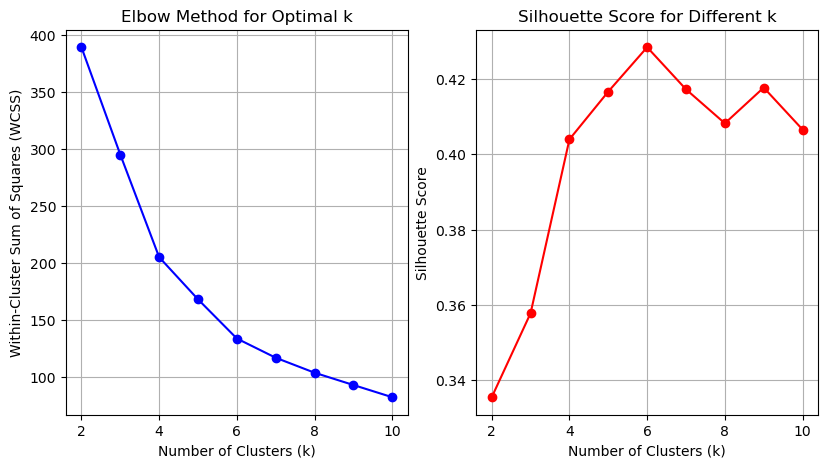

In [9]:
# Step 5: Determine optimal number of clusters using Elbow Method
print("\nStep 5: Finding optimal number of clusters...")

inertias = []
silhouette_scores = []
k_range = range(2, 11)  # Start from 2 for silhouette score

print("Calculating WCSS and Silhouette scores...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_avg = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)

# Plot elbow method
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(k_range, silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different k')
plt.grid(True)

# Choose optimal k (you can modify this logic)
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal k based on silhouette score: {optimal_k}")


In [10]:
# Step 6: Apply K-means clustering
print(f"\nStep 6: Applying K-means clustering with k={optimal_k}...")

# Fit final K-means model
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataframe
df['Cluster'] = cluster_labels
print(f"Clustering completed! Created {optimal_k} clusters")


Step 6: Applying K-means clustering with k=6...
Clustering completed! Created 6 clusters


In [11]:
# Step 7: Analyze clusters
print("\nStep 7: Cluster Analysis...")

# Cluster summary statistics
print("Cluster Summary Statistics:")
cluster_summary = df.groupby('Cluster')[clustering_features].mean()
print(cluster_summary)

print(f"\nCluster sizes:")
cluster_counts = df['Cluster'].value_counts().sort_index()
print(cluster_counts)


Step 7: Cluster Analysis...
Cluster Summary Statistics:
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        56.333333           54.266667               49.066667
1        26.794872           57.102564               48.128205
2        41.939394           88.939394               16.969697
3        32.692308           86.538462               82.128205
4        25.000000           25.260870               77.608696
5        45.523810           26.285714               19.380952

Cluster sizes:
Cluster
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64



Step 8: Creating cluster visualizations...


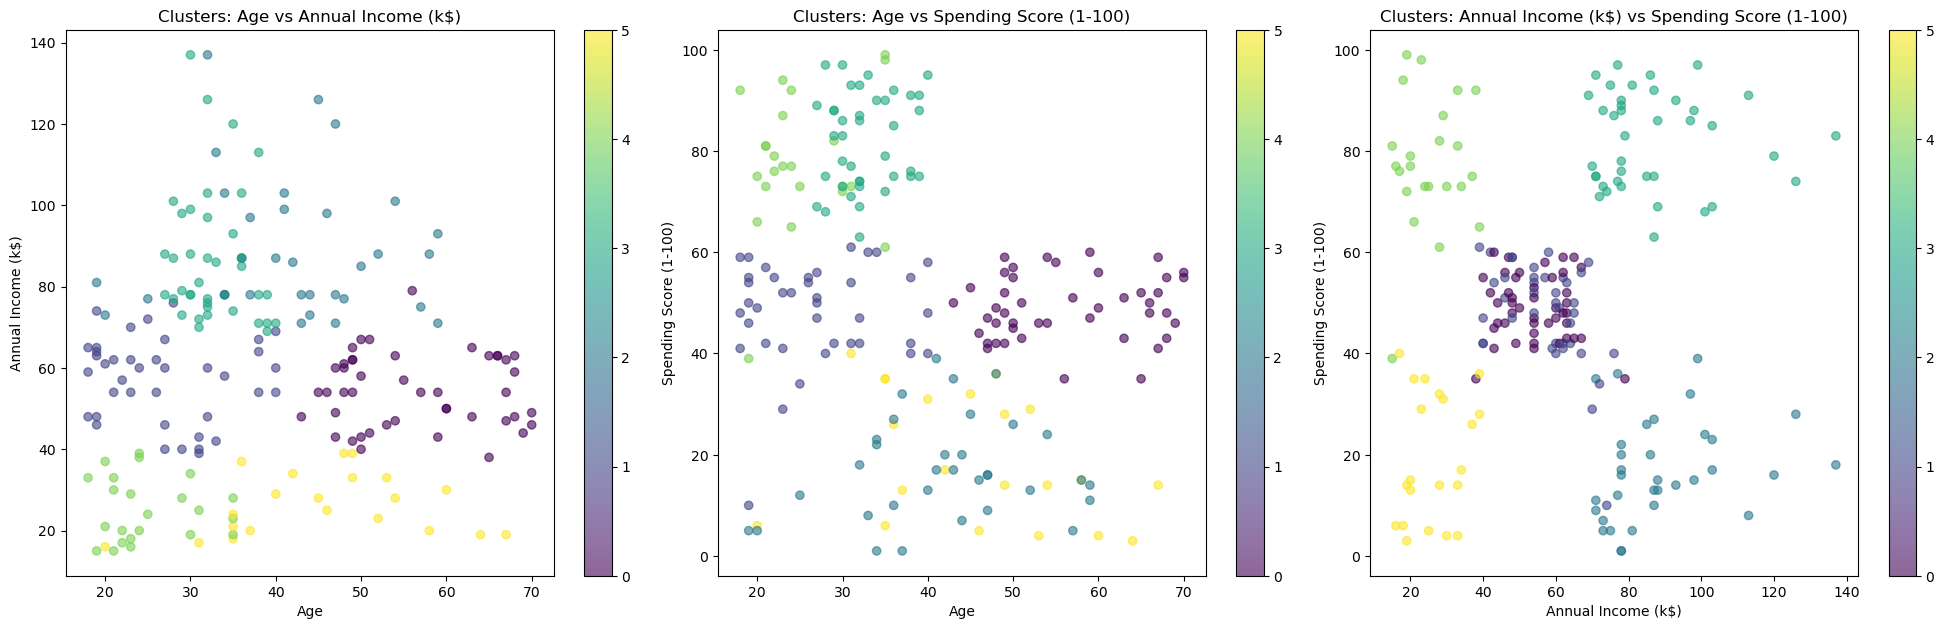

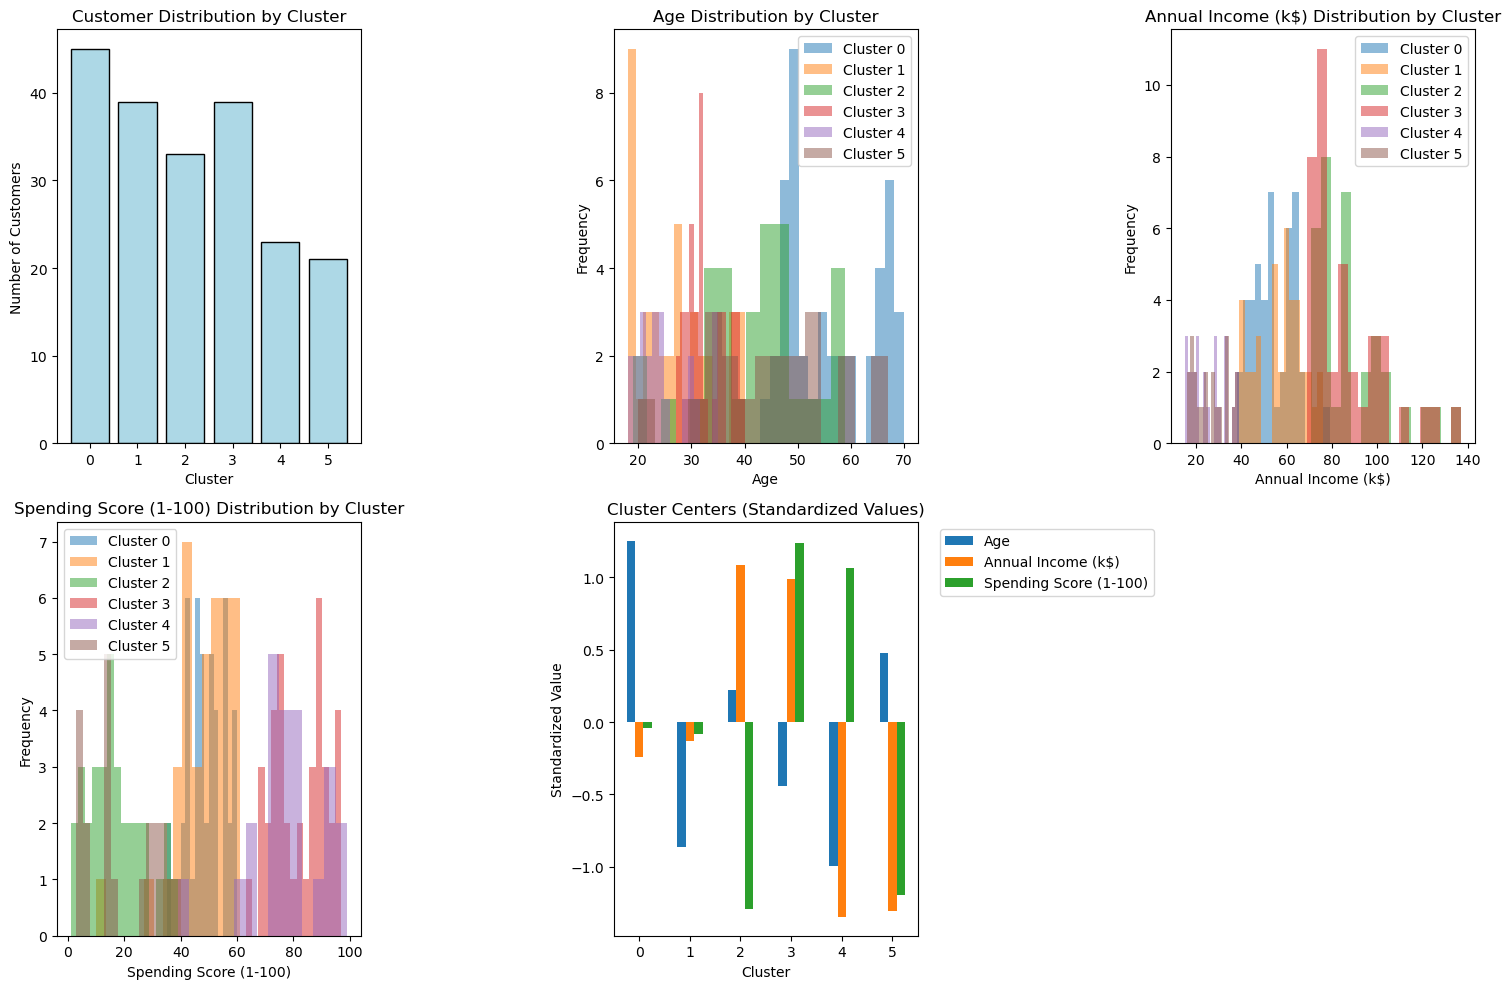

In [12]:
# Step 8: Visualize clusters
print("\nStep 8: Creating cluster visualizations...")

plt.figure(figsize=(20, 12))

# Determine number of feature combinations to plot
n_features = len(clustering_features)
plot_count = 0

# Plot pairwise feature combinations
for i in range(n_features):
    for j in range(i+1, n_features):
        if plot_count < 6:  # Limit to 6 plots
            plt.subplot(2, 3, plot_count + 1)
            scatter = plt.scatter(df[clustering_features[i]], df[clustering_features[j]], 
                                c=df['Cluster'], cmap='viridis', alpha=0.6)
            plt.xlabel(clustering_features[i])
            plt.ylabel(clustering_features[j])
            plt.title(f'Clusters: {clustering_features[i]} vs {clustering_features[j]}')
            plt.colorbar(scatter)
            plot_count += 1

plt.tight_layout()
plt.show()

# Additional visualizations
plt.figure(figsize=(15, 10))

# Cluster distribution
plt.subplot(2, 3, 1)
plt.bar(cluster_counts.index, cluster_counts.values, color='lightblue', edgecolor='black')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Customer Distribution by Cluster')

# Feature distributions by cluster
for idx, feature in enumerate(clustering_features[:3]):  # Plot first 3 features
    plt.subplot(2, 3, idx + 2)
    for cluster in sorted(df['Cluster'].unique()):
        cluster_data = df[df['Cluster'] == cluster][feature]
        plt.hist(cluster_data, alpha=0.5, label=f'Cluster {cluster}', bins=15)
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.title(f'{feature} Distribution by Cluster')
    plt.legend()

# Cluster centers visualization
plt.subplot(2, 3, 5)
centers_df = pd.DataFrame(final_kmeans.cluster_centers_, 
                         columns=clustering_features)
centers_df.plot(kind='bar', ax=plt.gca())
plt.title('Cluster Centers (Standardized Values)')
plt.xlabel('Cluster')
plt.ylabel('Standardized Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [13]:
# Step 9: Interpret clusters
print("\nStep 9: Customer Segment Interpretation...")

def interpret_clusters(df, cluster_summary, features):
    print("Customer Segment Profiles:")
    print("=" * 60)
    
    for cluster in sorted(df['Cluster'].unique()):
        cluster_data = df[df['Cluster'] == cluster]
        cluster_size = len(cluster_data)
        
        print(f"\nCluster {cluster}: ({cluster_size} customers, {cluster_size/len(df)*100:.1f}%)")
        
        # Print average values for each feature
        for feature in features:
            avg_value = cluster_summary.loc[cluster, feature]
            print(f"Average {feature}: {avg_value:.2f}")
        
        # Create simple persona based on relative values
        feature_values = [cluster_summary.loc[cluster, f] for f in features]
        feature_ranks = [sum(1 for other_cluster in cluster_summary.index 
                            if cluster_summary.loc[other_cluster, f] < cluster_summary.loc[cluster, f])
                        for f in features]
        
        high_features = [features[i] for i, rank in enumerate(feature_ranks) 
                        if rank >= len(cluster_summary) * 0.6]
        low_features = [features[i] for i, rank in enumerate(feature_ranks) 
                       if rank <= len(cluster_summary) * 0.4]
        
        persona_parts = []
        if high_features:
            persona_parts.append(f"High {', '.join(high_features)}")
        if low_features:
            persona_parts.append(f"Low {', '.join(low_features)}")
        
        persona = " & ".join(persona_parts) if persona_parts else "Average across all features"
        print(f"Profile: {persona}")
        print("-" * 40)

interpret_clusters(df, cluster_summary, clustering_features)


Step 9: Customer Segment Interpretation...
Customer Segment Profiles:

Cluster 0: (45 customers, 22.5%)
Average Age: 56.33
Average Annual Income (k$): 54.27
Average Spending Score (1-100): 49.07
Profile: High Age & Low Annual Income (k$)
----------------------------------------

Cluster 1: (39 customers, 19.5%)
Average Age: 26.79
Average Annual Income (k$): 57.10
Average Spending Score (1-100): 48.13
Profile: Low Age, Spending Score (1-100)
----------------------------------------

Cluster 2: (33 customers, 16.5%)
Average Age: 41.94
Average Annual Income (k$): 88.94
Average Spending Score (1-100): 16.97
Profile: High Annual Income (k$) & Low Spending Score (1-100)
----------------------------------------

Cluster 3: (39 customers, 19.5%)
Average Age: 32.69
Average Annual Income (k$): 86.54
Average Spending Score (1-100): 82.13
Profile: High Annual Income (k$), Spending Score (1-100) & Low Age
----------------------------------------

Cluster 4: (23 customers, 11.5%)
Average Age: 25.00

In [14]:
# Step 10: Cluster quality assessment
print("\nStep 10: Cluster Quality Assessment...")

final_silhouette = silhouette_score(X_scaled, cluster_labels)
final_inertia = final_kmeans.inertia_

print(f"Final Silhouette Score: {final_silhouette:.4f}")
print(f"Final WCSS (Inertia): {final_inertia:.2f}")

if final_silhouette > 0.5:
    print("✓ Excellent cluster separation")
elif final_silhouette > 0.3:
    print("✓ Good cluster separation")
elif final_silhouette > 0.1:
    print("✓ Reasonable cluster separation")
else:
    print("⚠ Poor cluster separation - consider different approach")


Step 10: Cluster Quality Assessment...
Final Silhouette Score: 0.4284
Final WCSS (Inertia): 133.87
✓ Good cluster separation


In [15]:
# Step 11: Show sample customers from each cluster
print("\nStep 11: Sample Customers from Each Cluster...")

for cluster in sorted(df['Cluster'].unique()):
    print(f"\nCluster {cluster} - Sample Customers:")
    sample_customers = df[df['Cluster'] == cluster].head(3)
    display_columns = ['CustomerID'] + clustering_features + ['Cluster']
    # Only show columns that exist
    available_columns = [col for col in display_columns if col in df.columns]
    print(sample_customers[available_columns])


Step 11: Sample Customers from Each Cluster...

Cluster 0 - Sample Customers:
    CustomerID  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
40          41   65                  38                      35        0
46          47   50                  40                      55        0
50          51   49                  42                      52        0

Cluster 1 - Sample Customers:
    CustomerID  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
43          44   31                  39                      61        1
47          48   27                  40                      47        1
48          49   29                  40                      42        1

Cluster 2 - Sample Customers:
     CustomerID  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
126         127   43                  71                      35        2
128         129   59                  71                      11        2
130         131   47                  71             

In [16]:
# Step 12: Save results
print("\nStep 12: Creating final summary...")

# Create summary dataframe
summary_stats = pd.DataFrame({
    'Cluster': sorted(df['Cluster'].unique()),
    'Size': [len(df[df['Cluster'] == c]) for c in sorted(df['Cluster'].unique())],
    'Percentage': [len(df[df['Cluster'] == c])/len(df)*100 for c in sorted(df['Cluster'].unique())]
})

for feature in clustering_features:
    summary_stats[f'Avg_{feature}'] = [df[df['Cluster'] == c][feature].mean() 
                                      for c in sorted(df['Cluster'].unique())]

print("\nFinal Cluster Summary:")
print(summary_stats)


Step 12: Creating final summary...

Final Cluster Summary:
   Cluster  Size  Percentage    Avg_Age  Avg_Annual Income (k$)  \
0        0    45        22.5  56.333333               54.266667   
1        1    39        19.5  26.794872               57.102564   
2        2    33        16.5  41.939394               88.939394   
3        3    39        19.5  32.692308               86.538462   
4        4    23        11.5  25.000000               25.260870   
5        5    21        10.5  45.523810               26.285714   

   Avg_Spending Score (1-100)  
0                   49.066667  
1                   48.128205  
2                   16.969697  
3                   82.128205  
4                   77.608696  
5                   19.380952  


In [17]:
# Summary
print("\n" + "="*60)
print("TASK 2 COMPLETED: UNSUPERVISED LEARNING")
print("="*60)
print(f"✓ Algorithm: K-means Clustering")
print(f"✓ Number of Clusters: {optimal_k}")
print(f"✓ Silhouette Score: {final_silhouette:.4f}")
print(f"✓ Features Used: {', '.join(clustering_features)}")
print(f"✓ Total Customers Segmented: {len(df)}")
print("✓ Successfully identified customer segments for targeted marketing")
print("✓ Created cluster visualizations and interpretations")
print("="*60)


TASK 2 COMPLETED: UNSUPERVISED LEARNING
✓ Algorithm: K-means Clustering
✓ Number of Clusters: 6
✓ Silhouette Score: 0.4284
✓ Features Used: Age, Annual Income (k$), Spending Score (1-100)
✓ Total Customers Segmented: 200
✓ Successfully identified customer segments for targeted marketing
✓ Created cluster visualizations and interpretations


In [18]:
# Task 3: Reinforcement Learning - Simple Grid World
# Objective: Agent learns to navigate to a goal using Q-learning
# No external libraries required - pure Python implementation

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import random

print(" Grid World Navigation - Reinforcement Learning Task \n")

 Grid World Navigation - Reinforcement Learning Task 



In [20]:
# Step 1: Create gridworld environment 
class GridWorld:
    def __init__(self, size=5, start_pos=(0, 0), goal_pos=(4, 4), grid=None):
        self.size = size
        self.start_pos = start_pos
        self.goal_pos = goal_pos
        self.grid = grid if grid is not None else np.zeros((size, size))
        self.agent_pos = start_pos

    def reset(self):
        """Reset environment to start state"""
        self.agent_pos = self.start_pos
        return self.agent_pos

    def greedy_action(agent, state):
        """Choose the best action (greedy policy) without exploration"""
        if state in agent.q_table:
            return np.argmax(agent.q_table[state])
        else:
        # If state not in Q-table, choose random action
            return np.random.choice([0, 1, 2, 3])
    
    def step(self, action):
        """Take an action and return (next_state, reward, done)"""
        i, j = self.agent_pos

        # Actions: 0=up, 1=down, 2=left, 3=right
        if action == 0 and i > 0:
            i -= 1
        elif action == 1 and i < self.size - 1:
            i += 1
        elif action == 2 and j > 0:
            j -= 1
        elif action == 3 and j < self.size - 1:
            j += 1

        self.agent_pos = (i, j)

        # Rewards
        if self.agent_pos == self.goal_pos:
            return self.agent_pos, 1.0, True
        elif self.grid[i, j] == -1:  # obstacle
            return self.agent_pos, -1.0, True
        else:
            return self.agent_pos, -0.01, False  # small penalty

    def render(self):
        """Visualize the grid"""
        plt.figure(figsize=(5, 5))
        for i in range(self.size):
            for j in range(self.size):
                if (i, j) == self.start_pos:
                    plt.text(j, i, 'S', ha='center', va='center', fontsize=20, color='blue')
                elif (i, j) == self.goal_pos:
                    plt.text(j, i, 'G', ha='center', va='center', fontsize=20, color='green')
                elif (i, j) == self.agent_pos:
                    plt.text(j, i, 'A', ha='center', va='center', fontsize=20, color='red')
                elif self.grid[i, j] == -1:
                    plt.text(j, i, 'X', ha='center', va='center', fontsize=20, color='black')

        plt.title('Grid World Environment\nS=Start, G=Goal, A=Agent, X=Obstacle')
        plt.xticks(range(self.size))
        plt.yticks(range(self.size))
        plt.grid(True, alpha=0.3)
        plt.show()


In [21]:
#Q-Learning Agent
class QLearningAgent:
    def __init__(self, alpha=0.1, gamma=0.9, epsilon=1.0, epsilon_decay=0.995, min_epsilon=0.1):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.q_table = {}  # state -> action values

    def get_state_key(self, state):
        return tuple(state)
    
    def get_action(self, state, training=True):
        """Choose action using epsilon-greedy policy.
           If training=False → always choose greedy (best action)."""
        if training and np.random.rand() < self.eplison:
            return np.random.randit(self.action_size)
        return np.argmax(self.q_table[state])


    def choose_action(self, state):
        state_key = self.get_state_key(state)
        if state_key not in self.q_table:
            self.q_table[state_key] = np.zeros(4)  # 4 actions

        if random.uniform(0, 1) < self.epsilon:
            return random.randint(0, 3)  # explore
        else:
            return np.argmax(self.q_table[state_key])  # exploit

    def learn(self, state, action, reward, next_state):
        state_key = self.get_state_key(state)
        next_key = self.get_state_key(next_state)

        if state_key not in self.q_table:
            self.q_table[state_key] = np.zeros(4)
        if next_key not in self.q_table:
            self.q_table[next_key] = np.zeros(4)

        best_next = np.max(self.q_table[next_key])
        td_target = reward + self.gamma * best_next
        td_error = td_target - self.q_table[state_key][action]

        self.q_table[state_key][action] += self.alpha * td_error

In [22]:
#Training loop
def train_agent(agent, env, num_episodes=1000, max_steps=100):
    rewards = []
    lengths = []
    successes = []

    for ep in range(num_episodes):
        state = env.reset()
        total_reward = 0
        done = False

        for step in range(max_steps):
            action = agent.choose_action(state)
            next_state, reward, done = env.step(action)
            agent.learn(state, action, reward, next_state)

            state = next_state
            total_reward += reward

            if done:
                break

        rewards.append(total_reward)
        lengths.append(step + 1)

        if state == env.goal_pos:
            successes.append(1)
        else:
            successes.append(0)

        # Decay exploration
        agent.epsilon = max(agent.min_epsilon, agent.epsilon * agent.epsilon_decay)

    return rewards, lengths, successes

Starting training...
Training finished! Success rate = 496/500


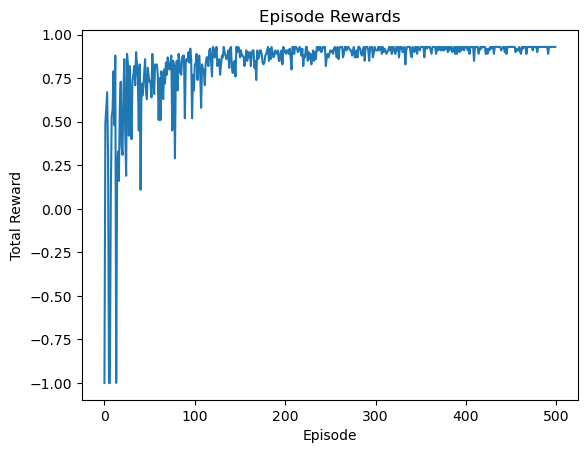

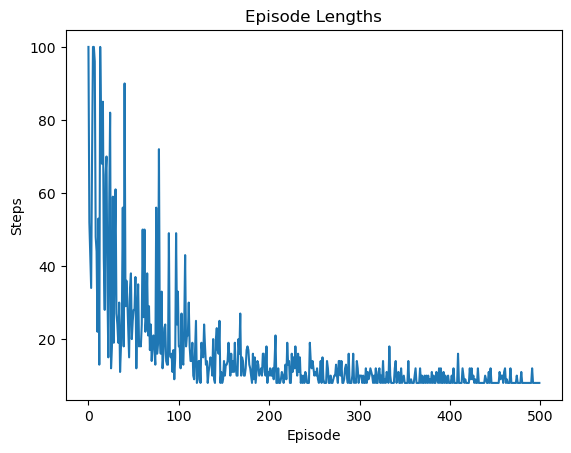

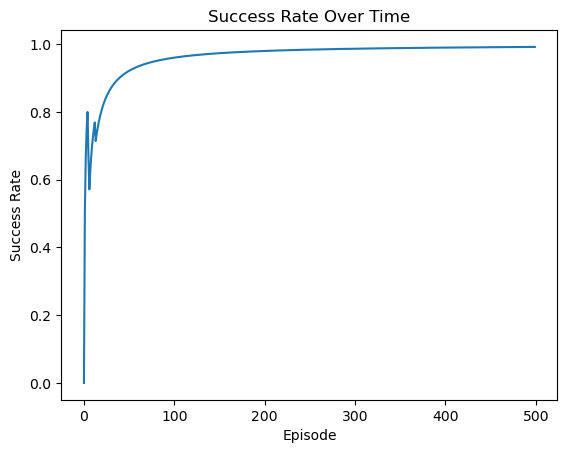

In [23]:
#run trainings and plot results
print("Starting training...")
env = GridWorld(size=5, start_pos=(0, 0), goal_pos=(4, 4))
agent = QLearningAgent()

rewards, lengths, successes = train_agent(agent, env, num_episodes=500)

print(f"Training finished! Success rate = {sum(successes)}/{len(successes)}")

# Plot Rewards
plt.plot(rewards)
plt.title("Episode Rewards")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

# Plot Episode Lengths
plt.plot(lengths)
plt.title("Episode Lengths")
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.show()

# Plot Success Rate
plt.plot(np.cumsum(successes) / (np.arange(len(successes)) + 1))
plt.title("Success Rate Over Time")
plt.xlabel("Episode")
plt.ylabel("Success Rate")
plt.show()

Text(0.5, 1.0, 'Q-values for "Right" Action')

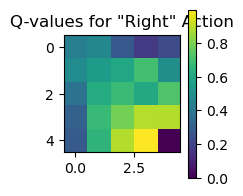

In [24]:
# Plot 4: Q-table heatmap (values for "right" action)
plt.subplot(2, 3, 4)
q_values_right = np.zeros((env.size, env.size))
for i in range(env.size):
    for j in range(env.size):
        q_values_right[i, j] = agent.q_table[(i, j)][3]  # Right action
plt.imshow(q_values_right, cmap='viridis')
plt.colorbar()
plt.title('Q-values for "Right" Action')


Step 7: Testing trained agent...
Testing agent for 5 episodes...
Test 1: SUCCESS in 8 steps, Reward: 0.93
Agent's path:
Step 0: (0, 0)
Step 1: (0, 1)
Step 2: (1, 1)
Step 3: (1, 2)
Step 4: (2, 2)
Step 5: (3, 2)
Step 6: (3, 3)
Step 7: (3, 4)
Step 8: (4, 4)


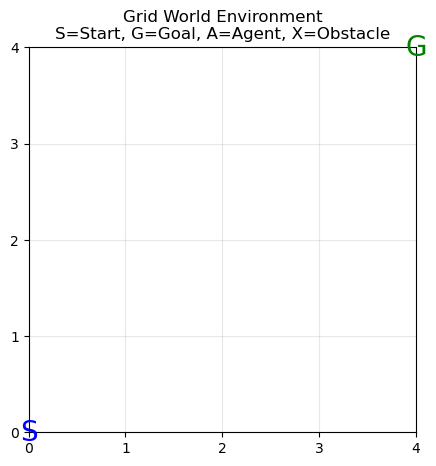

Test 2: SUCCESS in 8 steps, Reward: 0.93
Test 3: SUCCESS in 8 steps, Reward: 0.93
Test 4: SUCCESS in 8 steps, Reward: 0.93
Test 5: SUCCESS in 8 steps, Reward: 0.93


In [25]:
print("\nStep 7: Testing trained agent...")

def test_agent(agent, env, num_tests=5, render_path=True):
    """Test the trained agent"""
    print(f"Testing agent for {num_tests} episodes...")
    
    test_results = []
    
    for test in range(num_tests):
        state = env.reset()
        path = [state]
        total_reward = 0
        steps = 0
        
        for step in range(50):  # Max 50 steps
            # Use greedy policy (no epsilon exploration)
            state_key = agent.get_state_key(state)
            if state_key in agent.q_table:
                action = np.argmax(agent.q_table[state_key])
            else:
                action = np.random.randint(0, 4)  # fallback random action
            
            next_state, reward, done = env.step(action)
            
            path.append(next_state)
            state = next_state
            total_reward += reward
            steps += 1
            
            if done:
                break
        
        success = (state == env.goal_pos)
        test_results.append((success, steps, total_reward, path))
        
        print(f"Test {test+1}: {'SUCCESS' if success else 'FAILED'} in {steps} steps, Reward: {total_reward:.2f}")
        
        if render_path and test == 0:  # Show path for first test
            print("Agent's path:")
            for i, pos in enumerate(path):
                print(f"Step {i}: {pos}")
            env.render()
    
    return test_results


# Run tests
test_results = test_agent(agent, env)


Step 8: Visualizing learned policy...


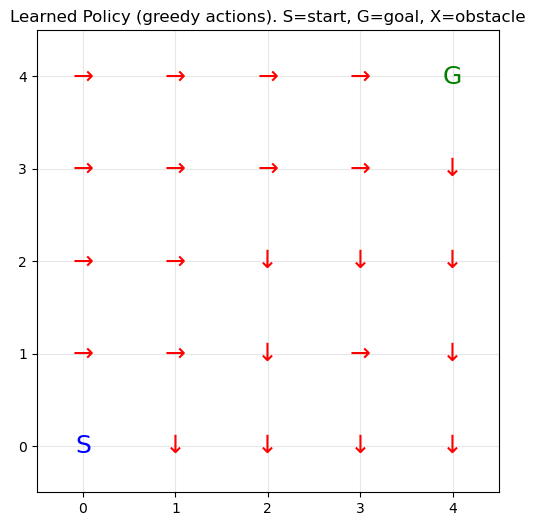

In [27]:
print("\nStep 8: Visualizing learned policy...")

def visualize_policy(agent, env):
    plt.figure(figsize=(6, 6))
    arrows = {0: '↑', 1: '↓', 2: '←', 3: '→'}

    # draw background (obstacles as -1, empty 0)
    plt.imshow(np.zeros((env.size, env.size)), cmap='Greys', alpha=0.0)  # blank background

    for i in range(env.size):
        for j in range(env.size):
            pos = (i, j)
            if pos == env.start_pos:
                plt.text(j, i, 'S', ha='center', va='center', fontsize=18, color='blue')
            elif pos == env.goal_pos:
                plt.text(j, i, 'G', ha='center', va='center', fontsize=18, color='green')
            elif env.grid[i, j] == -1:
                plt.text(j, i, 'X', ha='center', va='center', fontsize=18, color='black')
            else:
                # choose greedy action if available
                key = agent.get_state_key(pos)
                if key in agent.q_table:
                    best_action = int(np.argmax(agent.q_table[key]))
                    plt.text(j, i, arrows[best_action], ha='center', va='center', fontsize=18, color='red')
                else:
                    plt.text(j, i, '·', ha='center', va='center', fontsize=18, color='gray')  # unknown

    plt.title('Learned Policy (greedy actions). S=start, G=goal, X=obstacle')
    plt.xticks(range(env.size))
    plt.yticks(range(env.size))
    plt.grid(True, alpha=0.3)
    plt.gca().invert_yaxis()   # so (0,0) visually sits at top-left like your render
    plt.show()

visualize_policy(agent, env)


Step 9: Demonstrating optimal path (greedy policy)...
Starting at: (0, 0)
Step 1: Action Right -> (0, 1), Reward: -0.01
Step 2: Action Down -> (1, 1), Reward: -0.01
Step 3: Action Right -> (1, 2), Reward: -0.01
Step 4: Action Down -> (2, 2), Reward: -0.01
Step 5: Action Down -> (3, 2), Reward: -0.01
Step 6: Action Right -> (3, 3), Reward: -0.01
Step 7: Action Right -> (3, 4), Reward: -0.01
Step 8: Action Down -> (4, 4), Reward: 1.00
✅ Goal reached in 8 steps!

Final Environment State:


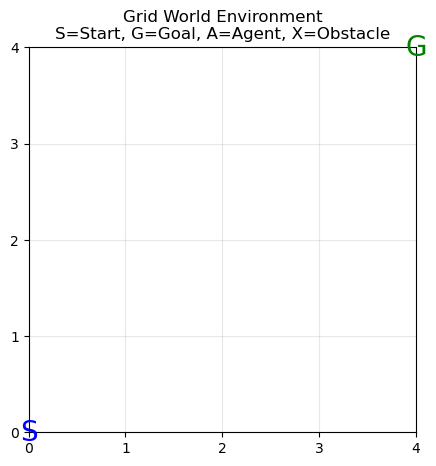

In [28]:
print("\nStep 9: Demonstrating optimal path (greedy policy)...")

state = env.reset()
optimal_path = [state]
print(f"Starting at: {state}")

for step in range(20):  # Max 20 steps
    # Use trained policy without exploration
    action = agent.get_action(state, training=False)
    next_state, reward, done = env.step(action)
    optimal_path.append(next_state)

    action_name = ['Up', 'Down', 'Left', 'Right'][action]
    print(f"Step {step+1}: Action {action_name} -> {next_state}, Reward: {reward:.2f}")

    state = next_state
    if done:
        if state == env.goal_pos:
            print(f"✅ Goal reached in {step+1} steps!")
        else:
            print(f"❌ Episode ended by obstacle in {step+1} steps.")
        break

# Show final render
print("\nFinal Environment State:")
env.render()


In [29]:
# Step 10: Summary and Analysis
print("\nStep 10: Final Analysis...")

# Calculate test statistics
successful_tests = sum(1 for result in test_results if result[0])
avg_steps = np.mean([result[1] for result in test_results if result[0]]) if successful_tests > 0 else None

print("\n" + "="*60)
print("TASK 3 COMPLETED: REINFORCEMENT LEARNING")
print("="*60)
print(f"✓ Environment: {env.size}x{env.size} Grid World")
print(f"✓ Algorithm: Q-Learning with epsilon-greedy exploration")

if 'episode_rewards' in globals():
    print(f"✓ Training Episodes: {len(episode_rewards)}")
    print(f"✓ Training Success Rate: {len(success_episodes)}/{len(episode_rewards)} "
          f"({len(success_episodes)/len(episode_rewards)*100:.1f}%)")
else:
    print("⚠ Training statistics not available (episode_rewards missing).")

print(f"✓ Test Success Rate: {successful_tests}/{len(test_results)} "
      f"({successful_tests/len(test_results)*100:.1f}%)")

if avg_steps is not None:
    print(f"✓ Average Steps to Goal (successful runs): {avg_steps:.1f}")

print(f"✓ Q-table Size: {len(agent.q_table)} states learned")
print("✓ Agent learned optimal navigation policy through trial and error")
print("✓ Demonstrated exploration vs exploitation trade-off")
print("="*60)



Step 10: Final Analysis...

TASK 3 COMPLETED: REINFORCEMENT LEARNING
✓ Environment: 5x5 Grid World
✓ Algorithm: Q-Learning with epsilon-greedy exploration
⚠ Training statistics not available (episode_rewards missing).
✓ Test Success Rate: 5/5 (100.0%)
✓ Average Steps to Goal (successful runs): 8.0
✓ Q-table Size: 25 states learned
✓ Agent learned optimal navigation policy through trial and error
✓ Demonstrated exploration vs exploitation trade-off
